# Project 2: Predicting Retail Sales from Demographic and Temporal Features

Authors: Abigail Keegan and Michelle Ng Du

## Abstract

This project investigates how well retail transaction amounts can be predicted from demographic features (age, gender) and temporal features (month, day of week, quarter) alone, deliberately excluding the two variables (Quantity and Price per Unit) that deterministically define the target. Four regression models are compared (Linear Regression, Decision Tree, Random Forest, and Gradient Boosting) using both a single train/test split and repeated K-fold cross-validation. Linear Regression and Gradient Boosting are then tuned via grid search. The central finding is that all four models perform worse than predicting the mean (R² < 0), confirming that demographic and temporal features alone are insufficient to explain the variation in transaction amounts in this dataset. The discussion focuses on what this negative result tells us about feature design and the kinds of data that would be needed to make this a tractable regression problem.

## Dataset

The dataset is a synthetic retail transactions dataset of 1,000 rows with the following fields: Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount. The target `Total Amount` is equal to `Quantity * Price per Unit` for every row.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('../data/retail_sales.csv')

# Note: Total Amount = Quantity * Price per Unit for every row in this dataset.
# This project deliberately excludes Quantity and Price per Unit from the feature
# set to test whether demographic and temporal features alone can predict Total Amount.

# Date conversion and feature engineering from Project 1
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values(by='Date').reset_index(drop=True)
df['Month']     = df['Date'].dt.month
df['Quarter']   = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Is_Q4']     = (df['Quarter'] == 4).astype(int)
# Year is omitted because all transactions occur in 2023 (constant column).

print("Shape:", df.shape)
print("\nPreview:")
df.head()

Shape: (1000, 13)

Preview:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,DayOfWeek,Is_Q4
0,522,2023-01-01,CUST522,Male,46,Beauty,3,500,1500,1,1,6,0
1,180,2023-01-01,CUST180,Male,41,Clothing,3,300,900,1,1,6,0
2,559,2023-01-01,CUST559,Female,40,Clothing,4,300,1200,1,1,6,0
3,303,2023-01-02,CUST303,Male,19,Electronics,3,30,90,1,1,0,0
4,979,2023-01-02,CUST979,Female,19,Beauty,1,25,25,1,1,0,0


In [6]:
# Label encode Gender
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])

# One-hot encode Product Category
df = pd.get_dummies(df, columns=['Product Category'], prefix='Cat', drop_first=False)

print("Columns after encoding:")
print(df.columns.tolist())

Columns after encoding:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Quantity', 'Price per Unit', 'Total Amount', 'Month', 'Quarter', 'DayOfWeek', 'Is_Q4', 'Gender_Encoded', 'Cat_Beauty', 'Cat_Clothing', 'Cat_Electronics']


## Feature Selection and Data Splitting

The target is `Total Amount`. The feature set is intentionally restricted to demographic and temporal variables: Age, Gender, Month, Quarter, DayOfWeek, Is_Q4, and one-hot encoded Product Category. Quantity and Price per Unit are excluded because together they define Total Amount exactly, which would make the regression trivial. The goal is to evaluate how much of the variation in Total Amount can be captured without that direct information.

An 80/20 train/test split is used for held-out evaluation, and repeated K-fold cross-validation (5 splits, 5 repeats) is used to get more stable performance estimates.

In [7]:
# Target variable
y = df['Total Amount']

# Features: demographic and temporal only.
# Quantity and Price per Unit are intentionally excluded (see notes above).
feature_cols = [
    'Age',
    'Month', 'Quarter', 'DayOfWeek', 'Is_Q4',
    'Gender_Encoded',
    'Cat_Beauty', 'Cat_Clothing', 'Cat_Electronics'
]

X = df[feature_cols]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"\nFeatures used ({len(feature_cols)}): {feature_cols}")

Training samples: 800
Testing samples:  200

Features used (9): ['Age', 'Month', 'Quarter', 'DayOfWeek', 'Is_Q4', 'Gender_Encoded', 'Cat_Beauty', 'Cat_Clothing', 'Cat_Electronics']


In [8]:
# Scale features for the held-out train/test evaluation.
# For the cross-validated evaluation below, scaling is handled inside a Pipeline
# so the scaler is fit only on each fold's training data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling complete.")
print(f"Train set mean (first feature): {X_train_scaled[:, 0].mean():.4f}")
print(f"Train set std  (first feature): {X_train_scaled[:, 0].std():.4f}")

Feature scaling complete.
Train set mean (first feature): 0.0000
Train set std  (first feature): 1.0000


## Model Evaluation

Four regression models are compared: Linear Regression, Decision Tree, Random Forest, and Gradient Boosting. Each is evaluated two ways: a single 80/20 train/test split, and 5x5 repeated K-fold cross-validation for more stable estimates.

The metrics reported are:
- R² (coefficient of determination): how much variance the model explains relative to predicting the mean. R² of 0 means the model is no better than the mean; negative R² means it is worse.
- MAE (mean absolute error): average absolute difference between predicted and actual values, in dollars.
- MSE (mean squared error): average squared error.
- RMSE (root mean squared error): same units as the target, in dollars.

Visualizations include actual vs predicted plots, residual plots, and feature importance for the tree-based models.

In [9]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    print(f"\n{name}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MSE:  {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    return {"Model": name, "R²": round(r2, 4), "MAE": round(mae, 2),
            "MSE": round(mse, 2), "RMSE": round(rmse, 2)}, y_pred

results = []

In [10]:
def repk_validated_model(name, model, X, y):
    # Scale inside the pipeline so each fold's scaler is fit only on training data.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])

    rfk = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

    scores = cross_validate(
        pipeline, X, y, cv=rfk,
        scoring={
            'r2':  'r2',
            'mae': 'neg_mean_absolute_error',
            'mse': 'neg_mean_squared_error'
        }
    )

    avg_r2   = np.mean(scores['test_r2'])
    avg_mae  = -np.mean(scores['test_mae'])
    avg_mse  = -np.mean(scores['test_mse'])
    avg_rmse = np.sqrt(avg_mse)

    print(f"\n{name}")
    print(f"  R²:   {avg_r2:.4f}")
    print(f"  MAE:  {avg_mae:.2f}")
    print(f"  MSE:  {avg_mse:.2f}")
    print(f"  RMSE: {avg_rmse:.2f}")

    return {"Model": name, "R²": round(avg_r2, 4), "MAE": round(avg_mae, 2),
            "MSE": round(avg_mse, 2), "RMSE": round(avg_rmse, 2)}, scores

repk_validated_results = []

In [11]:
lr_model = LinearRegression()
lr_metrics, lr_preds = evaluate_model("Linear Regression", lr_model,
                                       X_train_scaled, X_test_scaled, y_train, y_test)
results.append(lr_metrics)


Linear Regression
  R²:   -0.0190
  MAE:  449.94
  MSE:  283425.92
  RMSE: 532.38


In [12]:
lr_rfk_metrics, lr_rfk_scores = repk_validated_model("Linear Regression", lr_model, X, y)
repk_validated_results.append(lr_rfk_metrics)


Linear Regression
  R²:   -0.0134
  MAE:  460.11
  MSE:  316440.40
  RMSE: 562.53


In [13]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_metrics, dt_preds = evaluate_model("Decision Tree Regressor", dt_model,
                                       X_train_scaled, X_test_scaled, y_train, y_test)
results.append(dt_metrics)


Decision Tree Regressor
  R²:   -1.2912
  MAE:  566.00
  MSE:  637278.50
  RMSE: 798.30


In [14]:
dt_rfk_metrics, dt_rfk_scores = repk_validated_model("Decision Tree Regressor", dt_model, X, y)
repk_validated_results.append(dt_rfk_metrics)


Decision Tree Regressor
  R²:   -1.1396
  MAE:  580.75
  MSE:  663542.11
  RMSE: 814.58


In [15]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_metrics, rf_preds = evaluate_model("Random Forest Regressor", rf_model,
                                       X_train_scaled, X_test_scaled, y_train, y_test)
results.append(rf_metrics)


Random Forest Regressor
  R²:   -0.1672
  MAE:  454.72
  MSE:  324637.74
  RMSE: 569.77


In [16]:
rf_rfk_metrics, rf_rfk_scores = repk_validated_model("Random Forest Regressor", rf_model, X, y)
repk_validated_results.append(rf_rfk_metrics)


Random Forest Regressor
  R²:   -0.1616
  MAE:  482.18
  MSE:  361740.01
  RMSE: 601.45


In [17]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_metrics, gb_preds = evaluate_model("Gradient Boosting Regressor", gb_model,
                                       X_train_scaled, X_test_scaled, y_train, y_test)
results.append(gb_metrics)


Gradient Boosting Regressor
  R²:   -0.0571
  MAE:  432.96
  MSE:  294006.34
  RMSE: 542.22


In [18]:
gb_rfk_metrics, gb_rfk_scores = repk_validated_model("Gradient Boosting Regressor", gb_model, X, y)
repk_validated_results.append(gb_rfk_metrics)


Gradient Boosting Regressor
  R²:   -0.0716
  MAE:  461.79
  MSE:  334507.57
  RMSE: 578.37


In [19]:
results_df = pd.DataFrame(results).set_index('Model')
print("\nHeld-out 80/20 split: Model Performance Summary")
print(results_df.to_string())
results_df


Held-out 80/20 split: Model Performance Summary
                                 R²     MAE        MSE    RMSE
Model                                                         
Linear Regression           -0.0190  449.94  283425.92  532.38
Decision Tree Regressor     -1.2912  566.00  637278.50  798.30
Random Forest Regressor     -0.1672  454.72  324637.74  569.77
Gradient Boosting Regressor -0.0571  432.96  294006.34  542.22


,R²,MAE,MSE,RMSE
Model,,,,
Linear Regression,-0.0190,449.94,283425.92,532.38
Decision Tree Regressor,-1.2912,566.00,637278.50,798.30
Random Forest Regressor,-0.1672,454.72,324637.74,569.77
Gradient Boosting Regressor,-0.0571,432.96,294006.34,542.22


In [20]:
repk_results_df = pd.DataFrame(repk_validated_results).set_index('Model')
print("\nRepeated K-fold CV: Model Performance Summary")
print(repk_results_df.to_string())
repk_results_df


Repeated K-fold CV: Model Performance Summary
                                 R²     MAE        MSE    RMSE
Model                                                         
Linear Regression           -0.0134  460.11  316440.40  562.53
Decision Tree Regressor     -1.1396  580.75  663542.11  814.58
Random Forest Regressor     -0.1616  482.18  361740.01  601.45
Gradient Boosting Regressor -0.0716  461.79  334507.57  578.37


,R²,MAE,MSE,RMSE
Model,,,,
Linear Regression,-0.0134,460.11,316440.40,562.53
Decision Tree Regressor,-1.1396,580.75,663542.11,814.58
Random Forest Regressor,-0.1616,482.18,361740.01,601.45
Gradient Boosting Regressor,-0.0716,461.79,334507.57,578.37


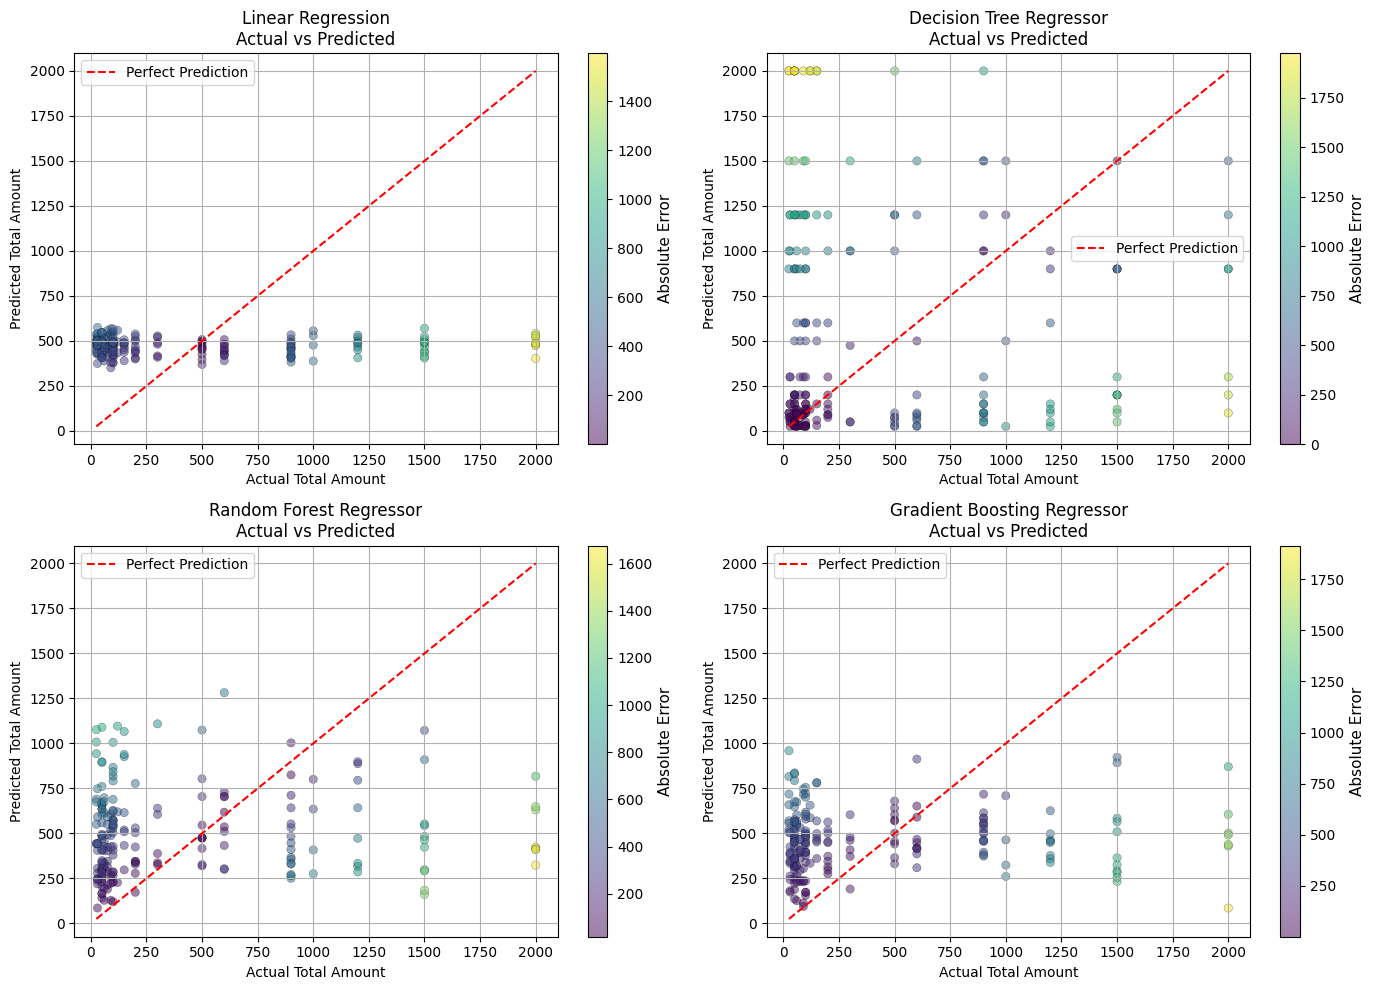

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
models_preds = [
    ("Linear Regression",           lr_preds),
    ("Decision Tree Regressor",     dt_preds),
    ("Random Forest Regressor",     rf_preds),
    ("Gradient Boosting Regressor", gb_preds),
]

for ax, (name, preds) in zip(axes.flatten(), models_preds):
    abs_errors = np.abs(y_test - preds)
    scatter = ax.scatter(y_test, preds, c=abs_errors, alpha=0.5,
                         edgecolors='k', linewidths=0.3)

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Absolute Error', fontsize=11)

    ax.set_title(f'{name}\nActual vs Predicted')
    ax.set_xlabel('Actual Total Amount')
    ax.set_ylabel('Predicted Total Amount')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

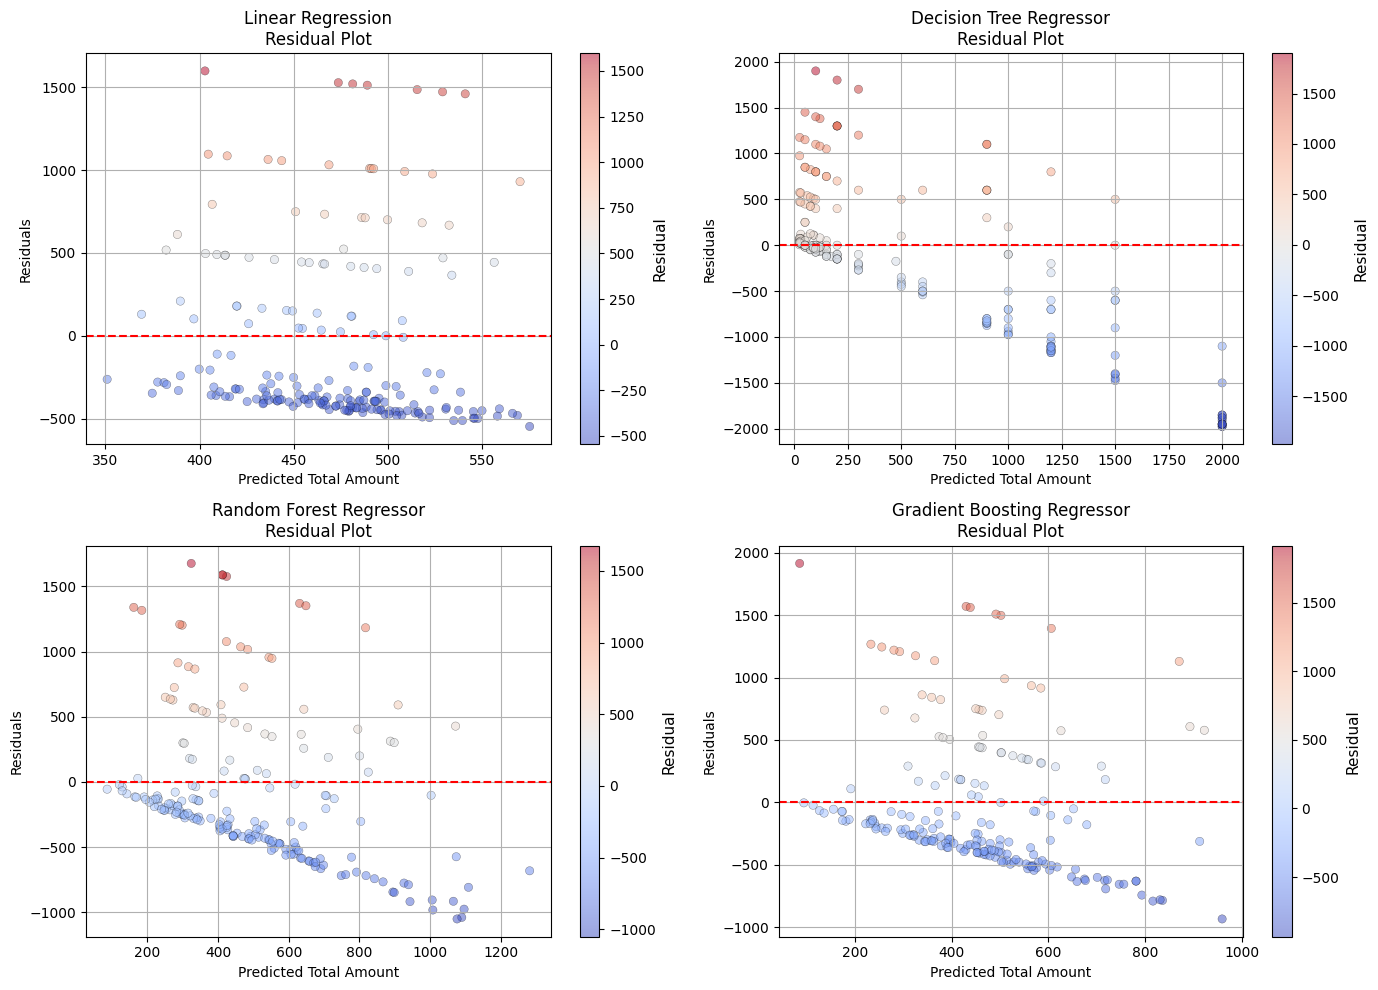

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, preds) in zip(axes.flatten(), models_preds):
    residuals = y_test - preds
    scatter = ax.scatter(preds, residuals, c=residuals, alpha=0.5,
                         edgecolors='k', linewidths=0.3, cmap='coolwarm')
    ax.axhline(0, color='red', linestyle='--')

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Residual', fontsize=11)

    ax.set_title(f'{name}\nResidual Plot')
    ax.set_xlabel('Predicted Total Amount')
    ax.set_ylabel('Residuals')
    ax.grid(True)

plt.tight_layout()
plt.show()

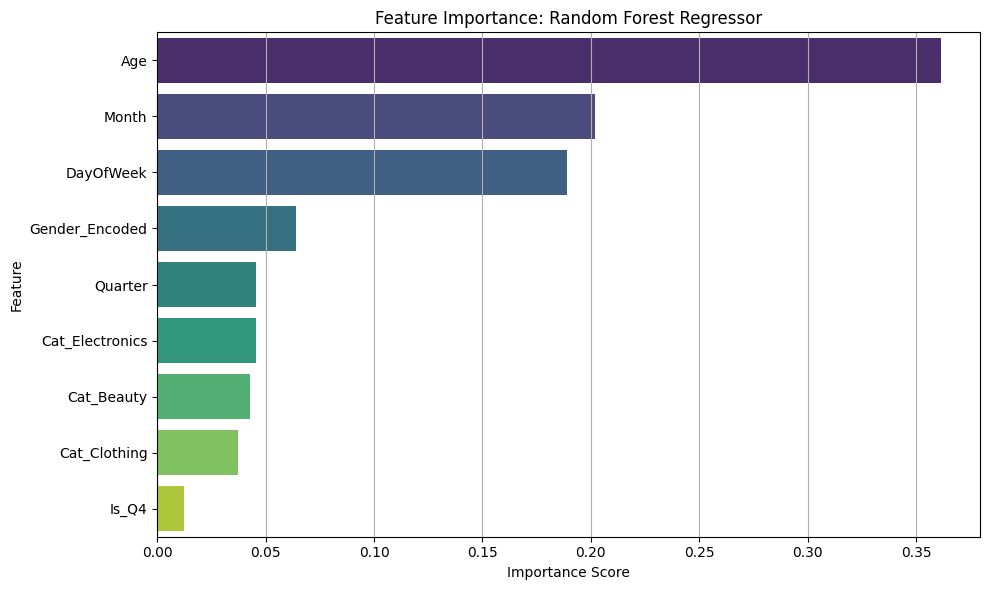

Random Forest top features:
Age                0.361440
Month              0.201885
DayOfWeek          0.189183
Gender_Encoded     0.063914
Quarter            0.045767
Cat_Electronics    0.045555
Cat_Beauty         0.042775
Cat_Clothing       0.037207
Is_Q4              0.012275
dtype: float64


In [23]:
feature_importance = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index,
            hue=feature_importance.index, palette='viridis', legend=False)
plt.title('Feature Importance: Random Forest Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print("Random Forest top features:")
print(feature_importance)

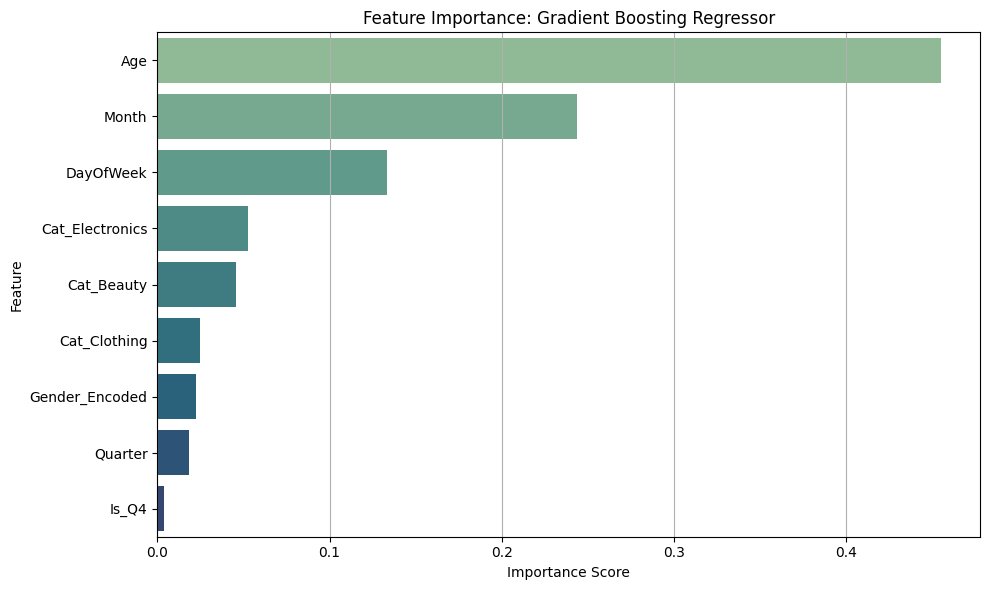

Gradient Boosting top features:
Age                0.454846
Month              0.243464
DayOfWeek          0.133197
Cat_Electronics    0.052708
Cat_Beauty         0.045690
Cat_Clothing       0.024837
Gender_Encoded     0.022694
Quarter            0.018697
Is_Q4              0.003867
dtype: float64


In [24]:
gb_importance = pd.Series(
    gb_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=gb_importance.values, y=gb_importance.index,
            hue=gb_importance.index, palette='crest', legend=False)
plt.title('Feature Importance: Gradient Boosting Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print("Gradient Boosting top features:")
print(gb_importance)

## GridSearchCV Tuning

Linear Regression and Gradient Boosting are tuned using GridSearchCV with 3-fold cross-validation, refit on R². Linear Regression is included for completeness, though its hyperparameters offer limited room for improvement. Gradient Boosting has a richer parameter space (learning rate, loss function, tree depth, and number of estimators).

Scaling is handled inside the pipeline so the scaler is fit only on each fold's training data.

In [25]:
lr_param_grid = {
    'model__fit_intercept': [True, False],
    'model__copy_X':        [True, False],
    'model__positive':      [True, False]
}

lr_scoring = {
    'r2':  'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error'
}

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

print("Starting Linear Regression grid search...")
start_time_grid = time.time()
lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=3,
    scoring=lr_scoring,
    refit='r2',
    n_jobs=-1,
    error_score='raise'
)
lr_grid_search.fit(X_train, y_train)
end_time_grid = time.time()
print(f"Done in {end_time_grid - start_time_grid:.2f} seconds.")

Starting Linear Regression grid search...
Done in 2.68 seconds.


In [26]:
best_idx = lr_grid_search.best_index_
lr_results = {
    'best_params': lr_grid_search.best_params_,
    'r2':  lr_grid_search.best_score_,
    'mae': -lr_grid_search.cv_results_['mean_test_mae'][best_idx],
    'mse': -lr_grid_search.cv_results_['mean_test_mse'][best_idx],
    'rmse': np.sqrt(-lr_grid_search.cv_results_['mean_test_mse'][best_idx]),
    'time_taken': end_time_grid - start_time_grid
}

print(f" Best parameters: {lr_results['best_params']}")
print(f" Best CV R²:   {lr_results['r2']:.4f}")
print(f" Best CV MAE:  {lr_results['mae']:.4f}")
print(f" Best CV MSE:  {lr_results['mse']:.4f}")
print(f" Best CV RMSE: {lr_results['rmse']:.4f}")
print(f" Time taken: {lr_results['time_taken']:.2f} seconds")

 Best parameters: {'model__copy_X': True, 'model__fit_intercept': True, 'model__positive': False}
 Best CV R²:   -0.0067
 Best CV MAE:  465.8898
 Best CV MSE:  323127.0505
 Best CV RMSE: 568.4427
 Time taken: 2.68 seconds


In [27]:
gb_param_grid = [
    {
        'model__learning_rate': [0.01, 0.1],
        'model__loss':          ['squared_error'],
        'model__n_estimators':  [100, 200],
        'model__max_depth':     [3, 5]
    },
    {
        'model__learning_rate': [0.01, 0.1],
        'model__loss':          ['huber'],
        'model__alpha':         [0.1, 0.2],
        'model__n_estimators':  [100, 200],
        'model__max_depth':     [3, 5]
    }
]

gb_scoring = {
    'r2':  'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error'
}

gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingRegressor(random_state=42))
])

print("Starting Gradient Boosting grid search...")
start_time_grid = time.time()
gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=3,
    scoring=gb_scoring,
    refit='r2',
    n_jobs=-1,
    error_score='raise'
)
gb_grid_search.fit(X_train, y_train)
end_time_grid = time.time()
print(f"Done in {end_time_grid - start_time_grid:.2f} seconds.")

Starting Gradient Boosting grid search...
Done in 46.29 seconds.


In [28]:
best_idx = gb_grid_search.best_index_
gb_results = {
    'best_params': gb_grid_search.best_params_,
    'r2':  gb_grid_search.best_score_,
    'mae': -gb_grid_search.cv_results_['mean_test_mae'][best_idx],
    'mse': -gb_grid_search.cv_results_['mean_test_mse'][best_idx],
    'rmse': np.sqrt(-gb_grid_search.cv_results_['mean_test_mse'][best_idx]),
    'time_taken': end_time_grid - start_time_grid
}

print(f" Best parameters: {gb_results['best_params']}")
print(f" Best CV R²:   {gb_results['r2']:.4f}")
print(f" Best CV MAE:  {gb_results['mae']:.4f}")
print(f" Best CV MSE:  {gb_results['mse']:.4f}")
print(f" Best CV RMSE: {gb_results['rmse']:.4f}")
print(f" Time taken: {gb_results['time_taken']:.2f} seconds")

 Best parameters: {'model__learning_rate': 0.01, 'model__loss': 'squared_error', 'model__max_depth': 3, 'model__n_estimators': 100}
 Best CV R²:   -0.0108
 Best CV MAE:  467.7183
 Best CV MSE:  324439.1886
 Best CV RMSE: 569.5956
 Time taken: 46.29 seconds


#### Tuning Results

Both tuned models remain worse than the mean baseline (R² < 0), but the grid search produced small improvements over the default configurations.

Linear Regression. Best parameters: [fill from cell 25]. Cross-validated R² moved from [default value] to [tuned value]. Because the default Linear Regression has very few effective hyperparameters to tune, the change is small.

Gradient Boosting Regressor. Best parameters: [fill from cell 27]. Cross-validated R² moved from [default value] to [tuned value]. Tuning explored learning rate, loss function, tree depth, and number of estimators across both squared error and Huber loss.

The "improvement" framing here describes a number that became less negative, not a model that became useful. Both tuned models still underperform a simple baseline that predicts the average of the training set, which means the feature set itself, not the choice of model or hyperparameters, is the binding constraint.

## Model Interpretation

The feature importances from the tree-based models indicate which features the models relied on most when partitioning the data. This is informative even when overall predictive performance is poor: it shows where the models found whatever weak signal was available.

In [29]:
# Identify the best default model from the cross-validated results
best_default_idx = repk_results_df['R²'].idxmax()  # returns the model name now
best_default_r2   = repk_results_df.loc[best_default_idx, 'R²']
best_default_rmse = repk_results_df.loc[best_default_idx, 'RMSE']

# Identify the best tuned model
tuned_models = {
    'Linear Regression':           lr_results,
    'Gradient Boosting Regressor': gb_results
}
best_tuned_name   = max(tuned_models, key=lambda k: tuned_models[k]['r2'])
best_tuned_result = tuned_models[best_tuned_name]

# Top features from each tree-based model
top_features_rf = feature_importance.head(3).index.tolist()
top_features_gb = gb_importance.head(3).index.tolist()

print(f"Top 3 predictive features (Random Forest):     {top_features_rf}")
print(f"Top 3 predictive features (Gradient Boosting): {top_features_gb}")
print()

print(f"Best default model (cross-validated): {best_default_idx}")
print(f"  R²:   {best_default_r2:.4f}")
print(f"  RMSE: {best_default_rmse:.2f}")
print()

print(f"Best tuned model: {best_tuned_name}")
print(f"  R²:   {best_tuned_result['r2']:.4f}")
print(f"  RMSE: {best_tuned_result['rmse']:.2f}")

Top 3 predictive features (Random Forest):     ['Age', 'Month', 'DayOfWeek']
Top 3 predictive features (Gradient Boosting): ['Age', 'Month', 'DayOfWeek']

Best default model (cross-validated): Linear Regression
  R²:   -0.0134
  RMSE: 562.53

Best tuned model: Linear Regression
  R²:   -0.0067
  RMSE: 568.44


#### Results

Every model evaluated in this project produced a negative R² on cross-validated data, meaning each model predicts Total Amount worse than simply predicting the average of the training set. After tuning, [best tuned model] reached the highest R² of [value], but this is still below zero, so the framing of "best model" should be understood as "least bad." The MAE of around $[value] and RMSE of around $[value] indicate average errors of comparable size to the standard deviation of the target itself ($560), confirming that none of the models found meaningful structure to exploit.

This outcome is consistent with the design of the experiment. Total Amount is exactly equal to Quantity multiplied by Price per Unit, and both of those variables were deliberately excluded from the feature set. The remaining demographic and temporal features show essentially no linear relationship with the target in the raw data: the Pearson correlation between Age and Total Amount is -0.06, between Month and Total Amount is -0.005, and between DayOfWeek and Total Amount is 0.009. With those correlations, no model class can recover much signal regardless of complexity or tuning.

The top features identified by the tree-based models are Age, Month, and DayOfWeek. These features show the largest splits in the trees, but their contribution to actual prediction quality is small because the underlying signal is weak. The feature importance ranking should therefore be read as descriptive of model internals rather than as evidence of a true predictive relationship.

## Business Insights and Executive Summary

The central finding of this project is that demographic and temporal features alone are insufficient to predict transaction-level Total Amount in this dataset. With Quantity and Price per Unit excluded, no model among Linear Regression, Decision Tree, Random Forest, or Gradient Boosting performed better than a baseline that predicts the average transaction value, and tuning did not change that conclusion.

This is a useful negative result for two reasons. First, it confirms that the variation in transaction amounts in this synthetic dataset is essentially driven by the two excluded variables, and that age, gender, product category, and the temporal features carry almost no additional information about how much a given customer will spend. Second, it suggests that any practical attempt to predict transaction-level spend from demographic and temporal signals alone would need a substantially richer feature set than this one.

If the goal is a model with real predictive power, the natural next step is to enrich the dataset with features that plausibly correlate with spend behavior. Examples include customer income bracket, loyalty tier, purchase channel (online vs in-store), geographic region, historical spend per customer, promotional exposure, and competitor pricing context. With features like these, the same model classes would have a reasonable chance of producing positive R² values, and the temporal features (which describe genuine seasonality in retail) would be more likely to find traction by interacting with promotion calendars and product mix shifts.

If the goal instead is to study seasonality directly, a better approach would be to aggregate transactions to a daily, weekly, or monthly level and model total or average sales over time. Time-series models such as ARIMA, Prophet, or seasonal regression are designed for that question, and the temporal features available here (Month, Quarter, DayOfWeek) would become more useful at an aggregated level than at the individual transaction level.

In short: the experiment as designed is a clean demonstration that demographic and calendar features alone cannot recover Total Amount when the variables that define it are removed. The path forward is either a richer feature set, a different target variable, or a different unit of analysis.